# SmartDs Legacy-Quicklook-Style Profiles

This notebook recreates the **line/scatter/histogram-style outputs** from the old `batplotlib` `quicklook.py`, but using the current `starwinds-analysis` library and **without** Tecplot / VTK / PyVista.

Covered here:
- shell-integral line plots (mass loss, torque, open flux, axisymmetric flux fraction, energy flux)
- old-style scatter plots (`field vs radius`)
- compact replacement for the old monster histogram (`hist2d`)

Not covered here (placeholders included below):
- extracted Alfvén/current-sheet isosurfaces
- streamtraces / 3D streamline visualisation
- exact Tecplot 3D view state / annotations

## Setup

The sample file is a native 3D BATSRUS output from `sample_data/`.
We attach the BATSRUS + spherical recipe graphs through the library helper so derived SI quantities (`M_A`, `beta`, etc.) are available on demand.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from starwinds_analysis.data.samples import get_sample
from starwinds_analysis.smart_ds import SmartDs
from starwinds_analysis.quicklook2d import (
    plot_radius_quicklook,
    plot_shell_diagnostics,
    prepare_smartds_for_quicklook,
    quicklook_shell_figure,
)
from starwinds_analysis.analysis.fluxes import plot_energy_flux_profile, plot_open_flux_profile
from starwinds_analysis.analysis.mass_loss import plot_mass_loss_profile
from starwinds_analysis.analysis.torque import plot_torque_profile

plt.rcParams["figure.dpi"] = 120
STAR_RADIUS_M = 6.957e8
STAR_MASS_KG = 1.98847e30

In [2]:
sample_path = get_sample("3d__var_3_n00060000.plt")
sds = SmartDs.from_file(sample_path)
prepare_smartds_for_quicklook(sds, body_radius_m=STAR_RADIUS_M)

sample_path

'/Users/dagfev/Documents/starwinds/starwinds-analysis/sample_data/3d__var_1_n00000000.plt'

## Shell Radii (Legacy-Style Integration Grid)

The old quicklook used a dense, non-uniform set of shell radii. Here we use a smaller set by default so the notebook runs quickly, but the plot shapes are the same kind of diagnostics.

In [ ]:
# TODO this should be done by extracting the ACTUAL values. there is already code somewhere that uses the positive values on the x axis for which y and z are zero to determine the radii. 
radii = np.unique(np.concatenate([
    1.0 + np.array([0.0, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]),
    1.0 + np.geomspace(0.2, 20.0, 10),
]))
radii = radii[np.isfinite(radii)]

# Keep this modest for a notebook. Increase to ~24x48 or more for smoother shell diagnostics.
N_POLAR = 12
N_AZIMUTH = 24

radii

array([ 1.        ,  1.001     ,  1.003     ,  1.01      ,  1.03      ,
        1.1       ,  1.2       ,  1.33362011,  1.55651188,  1.92831777,
        2.54852737,  3.58309933,  5.30886938,  8.18762733, 12.98968501,
       21.        ])

## Modern Combined Shell Diagnostics (Quicklook2D Wrapper)

This single figure replaces several separate old quicklook outputs (`mass-loss`, `open-flux`, `axisymmetric-fraction`, `energy-loss`, and torque summaries).

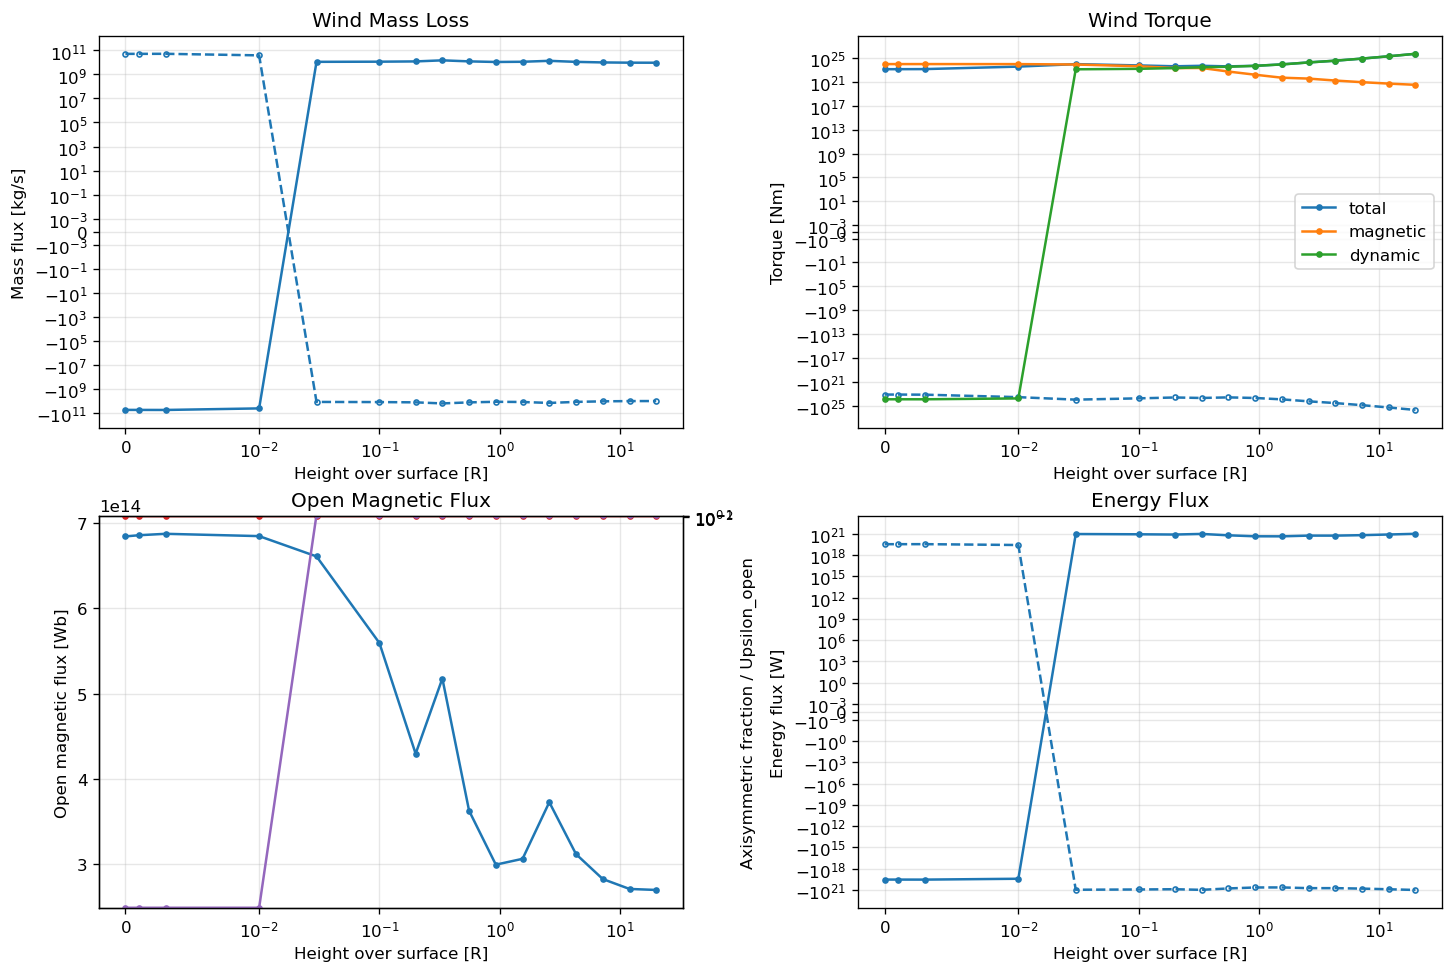

In [4]:
shell_fig, shell_axs, diagnostics = quicklook_shell_figure(
    sds,
    radii,
    body_radius_m=STAR_RADIUS_M,
    n_polar=N_POLAR,
    n_azimuth=N_AZIMUTH,
    method="nearest",
    star_mass_kg=STAR_MASS_KG,
)
plt.show()

## Legacy-Style Split Line Plots (Same Diagnostics, Separate Panels)

This cell reconstructs the old “one file per profile” style more directly, but still uses the new library-computed diagnostics.

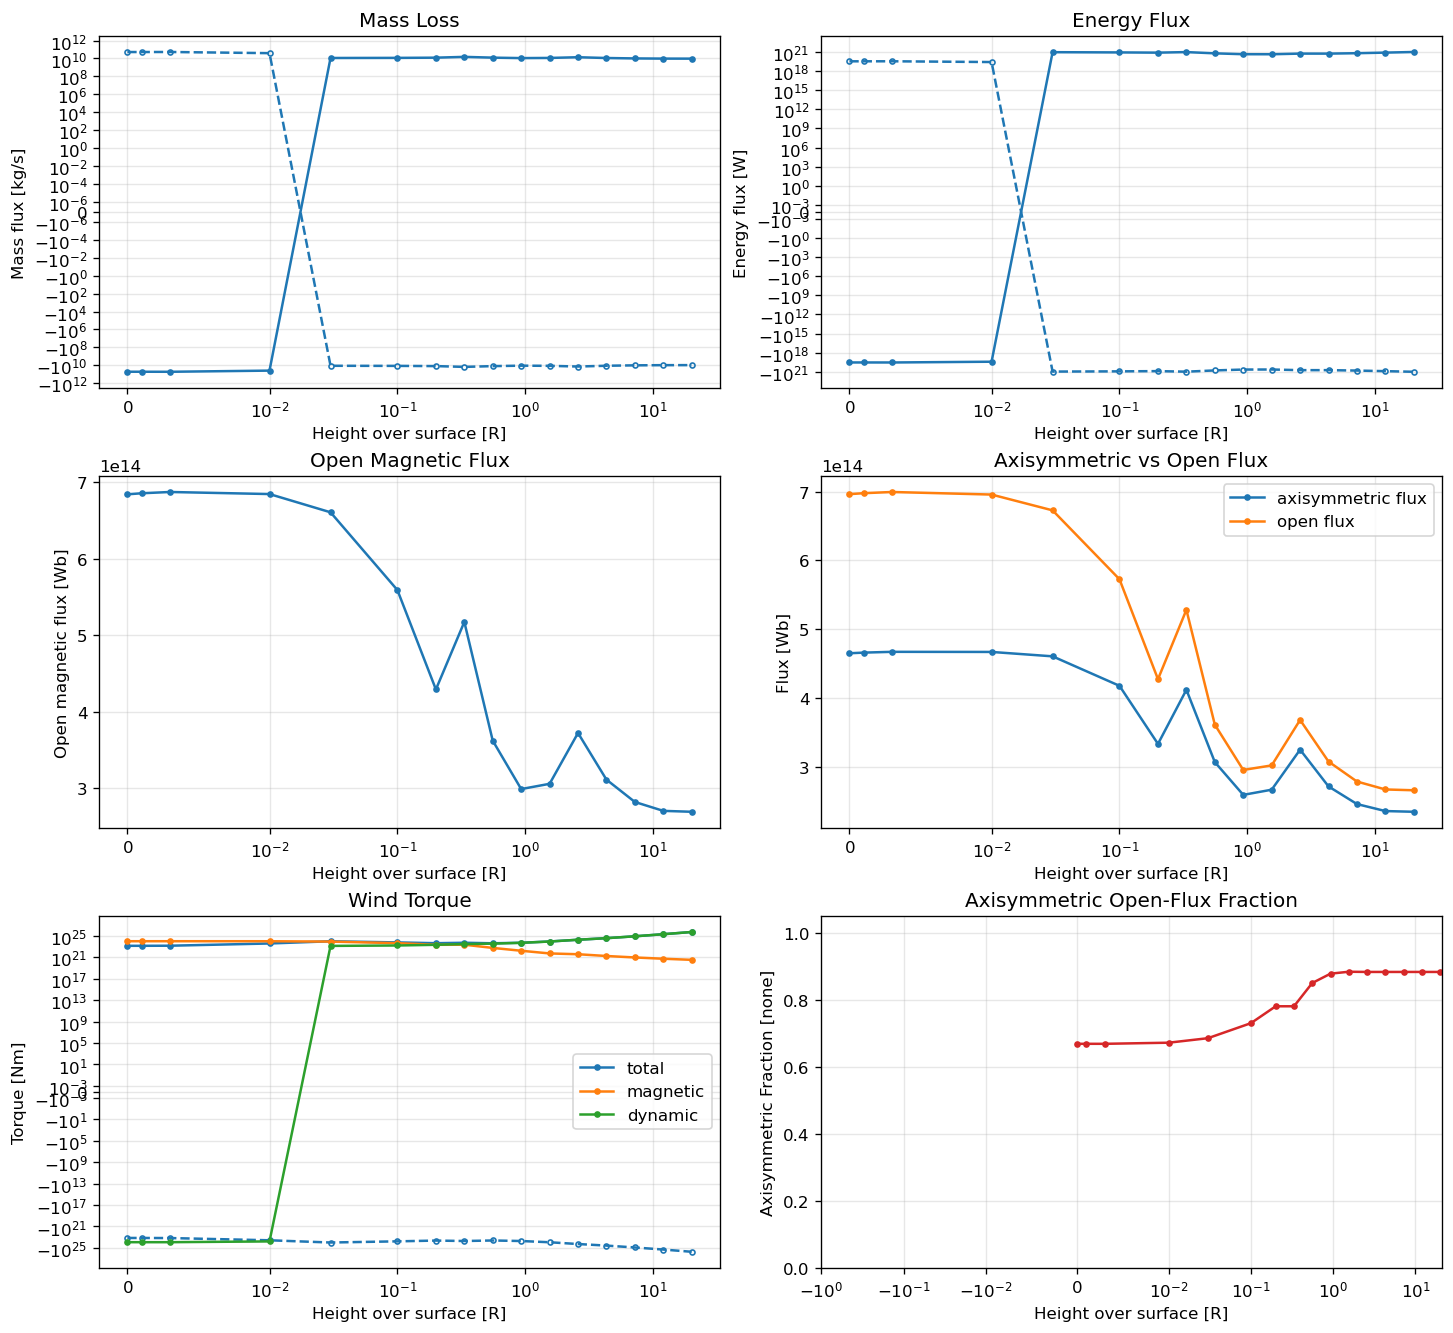

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)
axs = np.asarray(axs)

plot_mass_loss_profile(axs[0, 0], diagnostics["mass_loss"])
axs[0, 0].set_title("Mass Loss")
axs[0, 0].set_yscale("symlog", linthresh=1e-6)

plot_energy_flux_profile(axs[0, 1], diagnostics["energy"])
axs[0, 1].set_title("Energy Flux")
axs[0, 1].set_yscale("symlog", linthresh=1e-3)

plot_open_flux_profile(axs[1, 0], diagnostics["open_flux"])
axs[1, 0].set_title("Open Magnetic Flux")

axif = diagnostics.get("axisymmetric_open_flux")
if axif is not None:
    h = np.asarray(axif["height [R]"], dtype=float)
    axs[1, 1].plot(h, np.asarray(axif["axisymmetric_open_flux [Wb]"], dtype=float), ".-", label="axisymmetric flux")
    axs[1, 1].plot(h, np.asarray(axif["open_flux [Wb]"], dtype=float), ".-", label="open flux")
    axs[1, 1].set_ylabel("Flux [Wb]")
    axs[1, 1].set_title("Axisymmetric vs Open Flux")
    axs[1, 1].legend(loc="best")
else:
    axs[1, 1].text(0.5, 0.5, "axisymmetric_open_flux not computed", ha="center", va="center")

plot_torque_profile(axs[2, 0], diagnostics["torque"])
axs[2, 0].set_title("Wind Torque")
axs[2, 0].set_yscale("symlog", linthresh=1e-3)
axs[2, 0].legend(loc="best")

if axif is not None:
    h = np.asarray(axif["height [R]"], dtype=float)
    frac = np.asarray(axif["axisymmetric_open_flux_fraction [none]"], dtype=float)
    axs[2, 1].plot(h, frac, ".-", color="C3")
    axs[2, 1].set_ylabel("Axisymmetric Fraction [none]")
    axs[2, 1].set_ylim(0, 1.05)
    axs[2, 1].set_title("Axisymmetric Open-Flux Fraction")
else:
    axs[2, 1].text(0.5, 0.5, "axisymmetric_open_flux not computed", ha="center", va="center")

for ax in axs.ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)

for ax in axs[1:, :].ravel():
    ax.set_xlabel("Height over surface [R]")
plt.show()

## Old Quicklook-Style Scatter Plots (`field` vs `radius`)

These are direct point plots (no shell averaging), analogous to the optional `scatter_plots=True` path in the old quicklook.

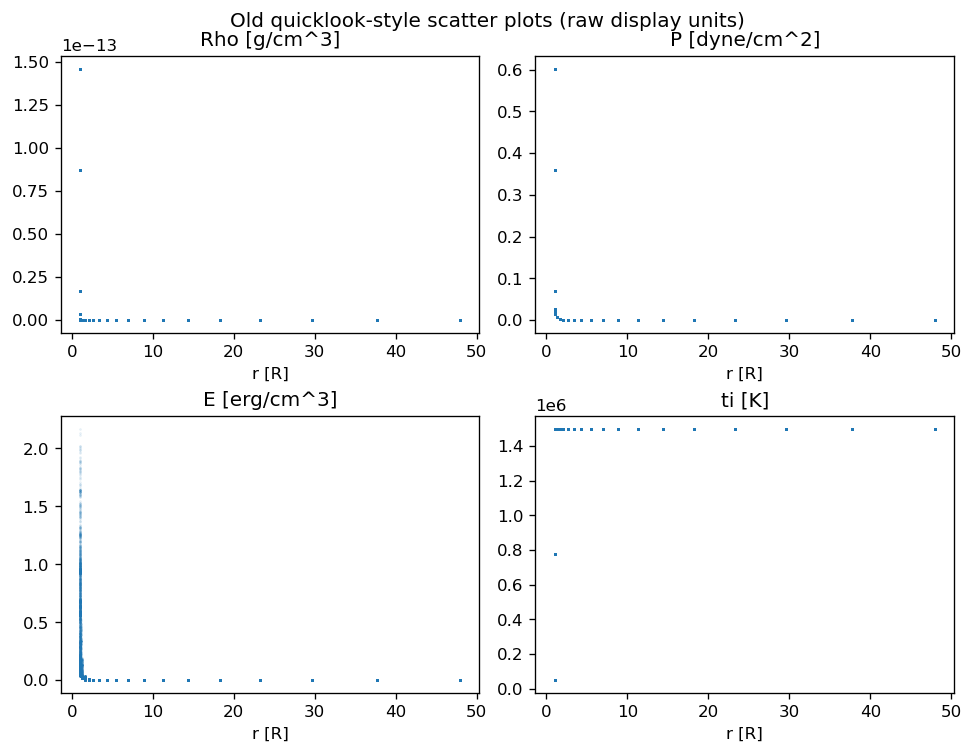

In [6]:
raw_scatter_fields = tuple(
    f for f in (
        "Rho [g/cm^3]",
        "P [dyne/cm^2]",
        "E [erg/cm^3]",
        "ti [K]",
    )
    if sds.has_field(f)
)

fig, axs = plot_radius_quicklook(sds, fields=raw_scatter_fields, mode="scatter", ncols=2, s=0.2, alpha=0.12)
fig.suptitle("Old quicklook-style scatter plots (raw display units)", y=1.02)
plt.show()

## Binned Radial Profiles (SI-First)

This is a cleaner replacement for some of the old radial trend inspection plots, using SI or derived fields where available.

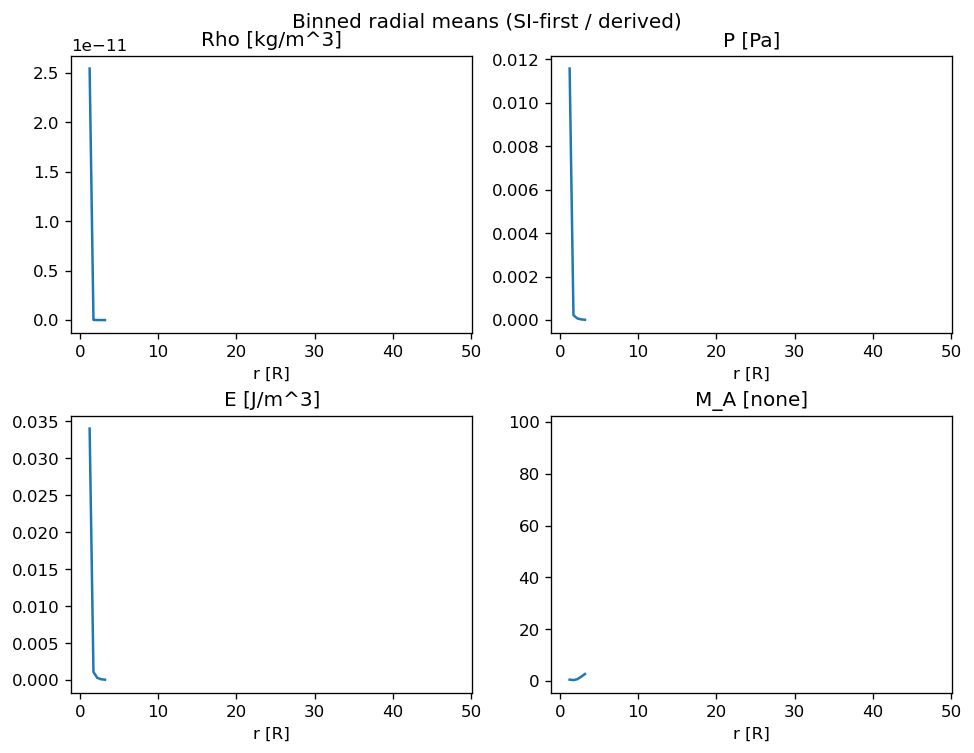

In [7]:
si_binned_fields = tuple(
    f for f in (
        "Rho [kg/m^3]",
        "P [Pa]",
        "E [J/m^3]",
        "M_A [none]",
    )
    if sds.has_field(f)
)

fig, axs = plot_radius_quicklook(sds, fields=si_binned_fields, mode="binned", ncols=2, bins=96, statistic="mean")
fig.suptitle("Binned radial means (SI-first / derived)", y=1.02)
plt.show()

## Histogram / Monster Replacement\n\nThis content is intentionally **not duplicated** here. Use `smartds_radial_histograms.ipynb` for the old monster-style replacement (`radial hist2d`) and related histogram/CDF plots.

## Placeholders: Old Quicklook Features That Still Need VTK/Tecplot-Like Geometry

These are intentionally **not** implemented in this notebook yet:

1. **Extracted Alfvén isosurface torque** (old quicklook overlaid Alfvén-surface torque markers in the torque plot).
2. **Current-sheet / Alfvén surface isosurface extraction and 3D rendering**.
3. **Streamtrace generation and visualization** (the old quicklook did Tecplot streamtraces).

The line/shell diagnostics above are still fully useful without these, and already cover the high-priority wind mass-loss and torque profiles.

In [9]:
print("Placeholder: Alfvén/current-sheet extracted surfaces and streamtraces are deferred (VTK/Tecplot geometry path).")

Placeholder: Alfvén/current-sheet extracted surfaces and streamtraces are deferred (VTK/Tecplot geometry path).
